In [1]:
import sys
import os
from pyspark.sql import SparkSession
import pyspark.sql.functions as s
from pyspark.sql.types import DoubleType, StringType

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

spark = SparkSession.builder \
    .appName("Testing PySpark Example") \
    .master("local[*]") \
    .config("spark.sql.parquet.enableVectorizedReader", "false") \
    .config("spark.driver.memory", "4g")\
    .getOrCreate()

C:\Users\savan\anaconda3\Lib\site-packages\pyspark\testing\utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


In [2]:
#read in the reduced files

df = spark.read.parquet("2014-2017_FINAL_CLEANED", "2018-2026_FINAL_CLEANED")

df.printSchema()

root
 |-- VendorID: double (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- PULocationID: double (nullable = true)
 |-- DOLocationID: double (nullable = true)
 |-- payment_type: double (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- trip_duration: double (nullable = true)
 |-- average_trip_speed: double (nullable = true)



In [3]:
df.show()

+--------+--------------------+---------------------+---------------+-------------+----------+------------+------------+------------+-----------+----------+------------+-------------------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|PULocationID|DOLocationID|payment_type|fare_amount|tip_amount|total_amount|      trip_duration|average_trip_speed|
+--------+--------------------+---------------------+---------------+-------------+----------+------------+------------+------------+-----------+----------+------------+-------------------+------------------+
|     2.0| 2014-01-01 00:00:00|  2014-01-01 00:10:00|            1.0|         3.65|       1.0|       114.0|        79.0|         2.0|       12.5|       0.0|        13.5|0.16666666666666666|21.900000000000002|
|     2.0| 2014-01-01 00:00:00|  2014-01-01 00:06:00|            2.0|         2.52|       1.0|       166.0|       142.0|         1.0|        8.5|       1.5|        

In [4]:
# Analysis of trends over time (annual)
# add additional columns for the year and hours of each data entry
df = df.withColumn("year",s.expr("""extract(YEAR from tpep_pickup_datetime)"""))
df = df.withColumn("hour_pickup",s.expr("""extract(HOUR from tpep_pickup_datetime)"""))
df = df.withColumn("hour_dropoff",s.expr("""extract(HOUR from tpep_dropoff_datetime)"""))
df.printSchema()

root
 |-- VendorID: double (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- PULocationID: double (nullable = true)
 |-- DOLocationID: double (nullable = true)
 |-- payment_type: double (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- trip_duration: double (nullable = true)
 |-- average_trip_speed: double (nullable = true)
 |-- year: integer (nullable = true)
 |-- hour_pickup: integer (nullable = true)
 |-- hour_dropoff: integer (nullable = true)



In [5]:
df.show()

+--------+--------------------+---------------------+---------------+-------------+----------+------------+------------+------------+-----------+----------+------------+-------------------+------------------+----+-----------+------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|PULocationID|DOLocationID|payment_type|fare_amount|tip_amount|total_amount|      trip_duration|average_trip_speed|year|hour_pickup|hour_dropoff|
+--------+--------------------+---------------------+---------------+-------------+----------+------------+------------+------------+-----------+----------+------------+-------------------+------------------+----+-----------+------------+
|     2.0| 2014-01-01 00:00:00|  2014-01-01 00:10:00|            1.0|         3.65|       1.0|       114.0|        79.0|         2.0|       12.5|       0.0|        13.5|0.16666666666666666|21.900000000000002|2014|          0|           0|
|     2.0| 2014-01-01 00:00:00|  2014-01-01 

In [6]:
#yearly operations -  average speed per year
from pyspark.sql.functions import avg

yearly_congestion_df = df.select(["year","average_trip_speed"])

annual_speeds = (
    yearly_congestion_df
    .groupBy("year")
    .agg(avg("average_trip_speed").alias("average_speed"))
    .orderBy("year")
)

annual_speeds.explain(True)
annual_speeds.show()



== Parsed Logical Plan ==
'Sort ['year ASC NULLS FIRST], true
+- Aggregate [year#72], [year#72, avg(average_trip_speed#13) AS average_speed#141]
   +- Project [year#72, average_trip_speed#13]
      +- Project [VendorID#0, tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_count#3, trip_distance#4, RatecodeID#5, PULocationID#6, DOLocationID#7, payment_type#8, fare_amount#9, tip_amount#10, total_amount#11, trip_duration#12, average_trip_speed#13, year#72, hour_pickup#73, extract(HOUR, tpep_dropoff_datetime#2) AS hour_dropoff#74]
         +- Project [VendorID#0, tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_count#3, trip_distance#4, RatecodeID#5, PULocationID#6, DOLocationID#7, payment_type#8, fare_amount#9, tip_amount#10, total_amount#11, trip_duration#12, average_trip_speed#13, year#72, extract(HOUR, tpep_pickup_datetime#1) AS hour_pickup#73]
            +- Project [VendorID#0, tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_count#3, trip_distance#4, Rate

In [7]:
#yearly operations -  average cost per mile per year

from pyspark.sql.functions import col

annual_cost_df = df.select(["year","trip_distance", "fare_amount"])
annual_cost_df = annual_cost_df.withColumn("cost_per_mile", col("fare_amount")/col("trip_distance"))

annual_cost = (
    annual_cost_df
    .groupBy("year")
    .agg(avg("cost_per_mile").alias("cost_per_mile"))
    .orderBy("year")
)

annual_cost.explain(True)
annual_cost.show()


== Parsed Logical Plan ==
'Sort ['year ASC NULLS FIRST], true
+- Aggregate [year#72], [year#72, avg(cost_per_mile#226) AS cost_per_mile#227]
   +- Project [year#72, trip_distance#4, fare_amount#9, (fare_amount#9 / trip_distance#4) AS cost_per_mile#226]
      +- Project [year#72, trip_distance#4, fare_amount#9]
         +- Project [VendorID#0, tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_count#3, trip_distance#4, RatecodeID#5, PULocationID#6, DOLocationID#7, payment_type#8, fare_amount#9, tip_amount#10, total_amount#11, trip_duration#12, average_trip_speed#13, year#72, hour_pickup#73, extract(HOUR, tpep_dropoff_datetime#2) AS hour_dropoff#74]
            +- Project [VendorID#0, tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_count#3, trip_distance#4, RatecodeID#5, PULocationID#6, DOLocationID#7, payment_type#8, fare_amount#9, tip_amount#10, total_amount#11, trip_duration#12, average_trip_speed#13, year#72, extract(HOUR, tpep_pickup_datetime#1) AS hour_pickup#73]

In [8]:
#yearly operations -  number of trips per year

from pyspark.sql.functions import sum as _sum

trip_vols_df = df.select(["year","passenger_count"])

trip_vols = (
    trip_vols_df
    .groupBy("year")
    .agg(_sum("passenger_count").alias("passenger_count"))
    .orderBy("year")
)


trip_vols.explain(True)
trip_vols.show()

== Parsed Logical Plan ==
'Sort ['year ASC NULLS FIRST], true
+- Aggregate [year#72], [year#72, sum(passenger_count#3) AS passenger_count#347]
   +- Project [year#72, passenger_count#3]
      +- Project [VendorID#0, tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_count#3, trip_distance#4, RatecodeID#5, PULocationID#6, DOLocationID#7, payment_type#8, fare_amount#9, tip_amount#10, total_amount#11, trip_duration#12, average_trip_speed#13, year#72, hour_pickup#73, extract(HOUR, tpep_dropoff_datetime#2) AS hour_dropoff#74]
         +- Project [VendorID#0, tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_count#3, trip_distance#4, RatecodeID#5, PULocationID#6, DOLocationID#7, payment_type#8, fare_amount#9, tip_amount#10, total_amount#11, trip_duration#12, average_trip_speed#13, year#72, extract(HOUR, tpep_pickup_datetime#1) AS hour_pickup#73]
            +- Project [VendorID#0, tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_count#3, trip_distance#4, RatecodeID

C:\Users\savan\anaconda3\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
C:\Users\savan\anaconda3\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
C:\Users\savan\anaconda3\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


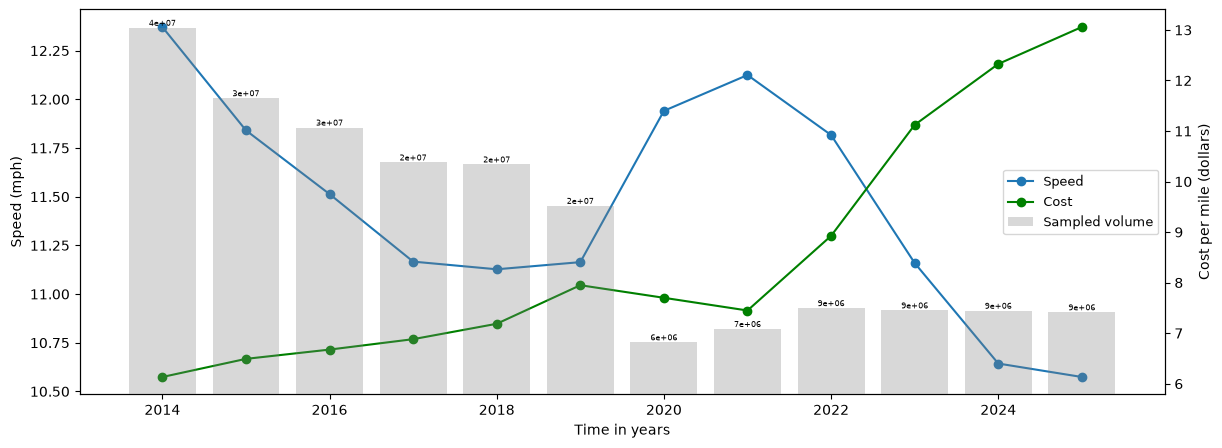

In [9]:
# create a chart for all the annual findings 
from matplotlib import pyplot as plt
from matplotlib.patches import Patch
annual_speeds_pd = annual_speeds.toPandas()
annual_cost_pd = annual_cost.toPandas()
trip_vols_pd = trip_vols.toPandas()

gig, axis1 = plt.subplots(figsize = (14, 5))
axis1.set_xlabel("Time in years")
axis1.set_ylabel("Speed (mph)")
line1, = axis1.plot(annual_speeds_pd["year"], annual_speeds_pd["average_speed"], marker = "o", zorder = 2)

axis2 = axis1.twinx()
axis2.set_ylabel("Cost per mile (dollars)")
line2, = axis2.plot(annual_cost_pd["year"], annual_cost_pd["cost_per_mile"], marker = "o", color = "green", zorder = 3)

axis3 = axis1.twinx()
axis3.spines['right'].set_position(('outward', 60))
axis3.spines['right'].set_visible(False)
axis3.set_frame_on(False)
axis3.tick_params(axis = 'y', left = False, right = False, labelleft = False, labelright = False)

bars = axis3.bar(trip_vols_pd["year"], trip_vols_pd["passenger_count"], zorder = 1, color = "gray", alpha = 0.3)

for rect, value in zip(bars, trip_vols_pd["passenger_count"]):
    axis3.text(
        rect.get_x()+rect.get_width()/2,
        rect.get_height(),
        f"{value:.0e}",
        ha = 'center', va = 'bottom', fontsize = 6

    )

bar_block = Patch(facecolor = 'gray', alpha = 0.3)
axis1.legend(handles = [line1, line2, bar_block], labels = ["Speed", "Cost", "Sampled volume"], loc = 'center right', fontsize = 9)

plt.savefig("annual trends")
plt.show()


In [10]:
# now similar to the above but with the daily trends (looking at hourly trends - with the start time hour as the proxy for hour)

hourly_congestion_df = df.select(["hour_pickup","average_trip_speed"])

hourly_speeds = (
    hourly_congestion_df
    .groupBy("hour_pickup")
    .agg(avg("average_trip_speed").alias("average_speed"))
    .orderBy("hour_pickup")
)

hourly_speeds.explain(True)
hourly_speeds.show()


== Parsed Logical Plan ==
'Sort ['hour_pickup ASC NULLS FIRST], true
+- Aggregate [hour_pickup#73], [hour_pickup#73, avg(average_trip_speed#13) AS average_speed#679]
   +- Project [hour_pickup#73, average_trip_speed#13]
      +- Project [VendorID#0, tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_count#3, trip_distance#4, RatecodeID#5, PULocationID#6, DOLocationID#7, payment_type#8, fare_amount#9, tip_amount#10, total_amount#11, trip_duration#12, average_trip_speed#13, year#72, hour_pickup#73, extract(HOUR, tpep_dropoff_datetime#2) AS hour_dropoff#74]
         +- Project [VendorID#0, tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_count#3, trip_distance#4, RatecodeID#5, PULocationID#6, DOLocationID#7, payment_type#8, fare_amount#9, tip_amount#10, total_amount#11, trip_duration#12, average_trip_speed#13, year#72, extract(HOUR, tpep_pickup_datetime#1) AS hour_pickup#73]
            +- Project [VendorID#0, tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_co

In [11]:
hourly_cost_df = df.select(["hour_pickup","trip_distance", "fare_amount"])
hourly_cost_df = hourly_cost_df.withColumn("cost_per_mile_h", col("fare_amount")/col("trip_distance"))

hourly_cost = (
    hourly_cost_df
    .groupBy("hour_pickup")
    .agg(avg("cost_per_mile_h").alias("cost_per_mile_h"))
    .orderBy("hour_pickup")
)

hourly_cost.explain(True)
hourly_cost.show()

== Parsed Logical Plan ==
'Sort ['hour_pickup ASC NULLS FIRST], true
+- Aggregate [hour_pickup#73], [hour_pickup#73, avg(cost_per_mile_h#764) AS cost_per_mile_h#765]
   +- Project [hour_pickup#73, trip_distance#4, fare_amount#9, (fare_amount#9 / trip_distance#4) AS cost_per_mile_h#764]
      +- Project [hour_pickup#73, trip_distance#4, fare_amount#9]
         +- Project [VendorID#0, tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_count#3, trip_distance#4, RatecodeID#5, PULocationID#6, DOLocationID#7, payment_type#8, fare_amount#9, tip_amount#10, total_amount#11, trip_duration#12, average_trip_speed#13, year#72, hour_pickup#73, extract(HOUR, tpep_dropoff_datetime#2) AS hour_dropoff#74]
            +- Project [VendorID#0, tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_count#3, trip_distance#4, RatecodeID#5, PULocationID#6, DOLocationID#7, payment_type#8, fare_amount#9, tip_amount#10, total_amount#11, trip_duration#12, average_trip_speed#13, year#72, extract(HOUR, t

In [12]:
trip_vols_h_df = df.select(["hour_pickup","passenger_count"])

trip_vols_hourly = (
    trip_vols_h_df
    .groupBy("hour_pickup")
    .agg(_sum("passenger_count").alias("passenger_count"))
    .orderBy("hour_pickup")
)

trip_vols_hourly.explain(True)
trip_vols_hourly.show()

== Parsed Logical Plan ==
'Sort ['hour_pickup ASC NULLS FIRST], true
+- Aggregate [hour_pickup#73], [hour_pickup#73, sum(passenger_count#3) AS passenger_count#885]
   +- Project [hour_pickup#73, passenger_count#3]
      +- Project [VendorID#0, tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_count#3, trip_distance#4, RatecodeID#5, PULocationID#6, DOLocationID#7, payment_type#8, fare_amount#9, tip_amount#10, total_amount#11, trip_duration#12, average_trip_speed#13, year#72, hour_pickup#73, extract(HOUR, tpep_dropoff_datetime#2) AS hour_dropoff#74]
         +- Project [VendorID#0, tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_count#3, trip_distance#4, RatecodeID#5, PULocationID#6, DOLocationID#7, payment_type#8, fare_amount#9, tip_amount#10, total_amount#11, trip_duration#12, average_trip_speed#13, year#72, extract(HOUR, tpep_pickup_datetime#1) AS hour_pickup#73]
            +- Project [VendorID#0, tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_count#3,

C:\Users\savan\anaconda3\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
C:\Users\savan\anaconda3\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
C:\Users\savan\anaconda3\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


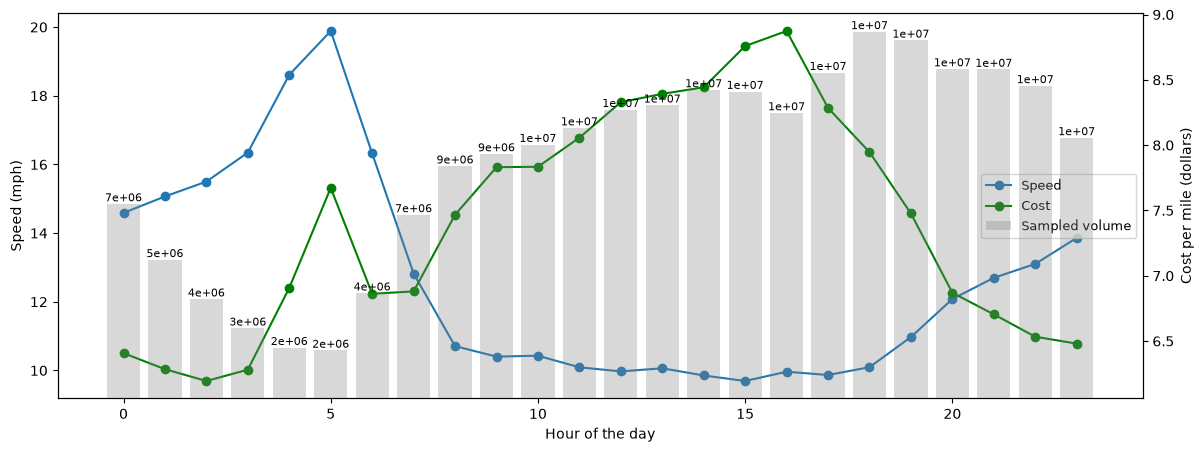

In [13]:
hourly_speeds_pd = hourly_speeds.toPandas()
hourly_cost_pd = hourly_cost.toPandas()
trip_vols_hourly_pd = trip_vols_hourly.toPandas()

gig, axis1 = plt.subplots(figsize = (14,5))
axis1.set_xlabel("Hour of the day")
axis1.set_ylabel("Speed (mph)")
line1, = axis1.plot(hourly_speeds_pd["hour_pickup"], hourly_speeds_pd["average_speed"], marker = "o", zorder = 2)

axis2 = axis1.twinx()
axis2.set_ylabel("Cost per mile (dollars)")
line2, = axis2.plot(hourly_cost_pd["hour_pickup"], hourly_cost_pd["cost_per_mile_h"], marker = "o", color = "green", zorder = 3)

axis3 = axis1.twinx()
axis3.spines['right'].set_position(('outward', 60))
axis3.spines['right'].set_visible(False)
axis3.set_frame_on(False)
axis3.tick_params(axis = 'y', left = False, right = False, labelleft = False, labelright = False)

bars = axis3.bar(trip_vols_hourly_pd["hour_pickup"], trip_vols_hourly_pd["passenger_count"], zorder = 1, color = "gray", alpha = 0.3)

for rect, value in zip(bars, trip_vols_hourly_pd["passenger_count"]):
    axis3.text(
        rect.get_x()+rect.get_width()/2,
        rect.get_height(),
        f"{value:.0e}",
        ha = 'center', va = 'bottom', fontsize = 8

    )

bar_block = Patch(facecolor = 'gray', alpha = 0.3)
axis1.legend(handles = [line1, line2, bar_block], labels = ["Speed", "Cost", "Sampled volume"], loc = 'center right', fontsize = 9)

plt.savefig("hourly trends")
plt.show()


In [14]:
#costs envelope over the years (per trip)
#outliers to be excluded from the min and max ranges with Q1-1.5IQR and Q3+1.5IQR formulae.
from pyspark.sql.functions import percentile_approx

annual_cost_per_trip_df = df.select(["year","trip_distance", "fare_amount"])

annual_cost_envelope = (
    annual_cost_per_trip_df
    .groupBy("year")
    .agg(
        avg("fare_amount").alias("fare_amount"),
        percentile_approx("fare_amount", 0.25).alias("Q1_amount"),
        percentile_approx("fare_amount", 0.75).alias("Q3_amount"),
        percentile_approx("fare_amount", 0.1).alias("lower_bound_amount"),
        avg("trip_distance").alias("average_distance"),
        percentile_approx("trip_distance", 0.25).alias("Q1_distance"),
        percentile_approx("trip_distance", 0.75).alias("Q3_distance"),
        percentile_approx("trip_distance", 0.1).alias("lower_bound_distance")
    )        
    .orderBy("year")
)

annual_cost_envelope.explain(True)
annual_cost_envelope.show()

== Parsed Logical Plan ==
'Sort ['year ASC NULLS FIRST], true
+- Aggregate [year#72], [year#72, avg(fare_amount#9) AS fare_amount#1217, percentile_approx(fare_amount#9, 0.25, 10000, 0, 0) AS Q1_amount#1218, percentile_approx(fare_amount#9, 0.75, 10000, 0, 0) AS Q3_amount#1219, percentile_approx(fare_amount#9, 0.1, 10000, 0, 0) AS lower_bound_amount#1220, avg(trip_distance#4) AS average_distance#1221, percentile_approx(trip_distance#4, 0.25, 10000, 0, 0) AS Q1_distance#1222, percentile_approx(trip_distance#4, 0.75, 10000, 0, 0) AS Q3_distance#1223, percentile_approx(trip_distance#4, 0.1, 10000, 0, 0) AS lower_bound_distance#1224]
   +- Project [year#72, trip_distance#4, fare_amount#9]
      +- Project [VendorID#0, tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_count#3, trip_distance#4, RatecodeID#5, PULocationID#6, DOLocationID#7, payment_type#8, fare_amount#9, tip_amount#10, total_amount#11, trip_duration#12, average_trip_speed#13, year#72, hour_pickup#73, extract(HOUR, tpe

In [20]:
from pyspark.sql.functions import round

cost_envelope_df = (
    annual_cost_envelope
        .withColumn("IQR_amount", col("Q3_amount")-col("Q1_amount"))
        .withColumn("IQR_distance", col("Q3_distance")-col("Q1_distance"))
)

cost_envelope_df = (
    cost_envelope_df
        .withColumn("Q1-1.5IQR_amount", round(col("Q1_amount")-1.5*col("IQR_amount"),1))
        .withColumn("Q3+1.5IQR_amount", round(col("Q3_amount")+1.5*col("IQR_amount"),1))
        .withColumn("Q1-1.5IQR_distance", round(col("Q1_distance")-1.5*col("IQR_distance"),1))
        .withColumn("Q3+1.5IQR_distance", round(col("Q3_distance")+1.5*col("IQR_distance"),1))
)

cost_envelope_df.explain()
cost_envelope_df.show()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [year#72, fare_amount#1217, Q1_amount#1218, Q3_amount#1219, lower_bound_amount#1220, average_distance#1221, Q1_distance#1222, Q3_distance#1223, lower_bound_distance#1224, IQR_amount#5741, IQR_distance#5742, round((Q1_amount#1218 - (IQR_amount#5741 * 1.5)), 1) AS Q1-1.5IQR_amount#5743, round((Q3_amount#1219 + (IQR_amount#5741 * 1.5)), 1) AS Q3+1.5IQR_amount#5744, round((Q1_distance#1222 - (IQR_distance#5742 * 1.5)), 1) AS Q1-1.5IQR_distance#5745, round((Q3_distance#1223 + (IQR_distance#5742 * 1.5)), 1) AS Q3+1.5IQR_distance#5746]
   +- Project [year#72, fare_amount#1217, Q1_amount#1218, Q3_amount#1219, lower_bound_amount#1220, average_distance#1221, Q1_distance#1222, Q3_distance#1223, lower_bound_distance#1224, (Q3_amount#1219 - Q1_amount#1218) AS IQR_amount#5741, (Q3_distance#1223 - Q1_distance#1222) AS IQR_distance#5742]
      +- Sort [year#72 ASC NULLS FIRST], true, 0
         +- Exchange rangepartitioning(year#72 ASC

C:\Users\savan\anaconda3\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


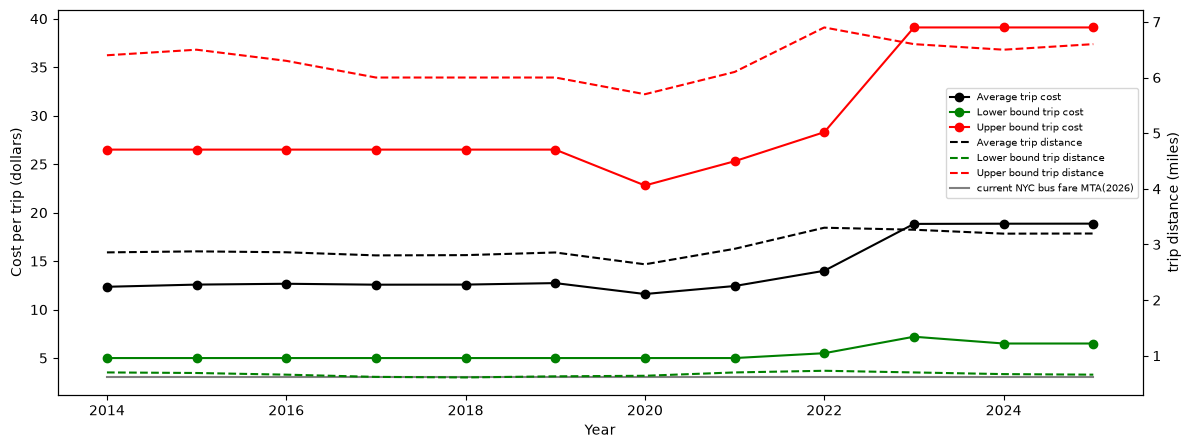

In [16]:
cost_envelope_pd = cost_envelope_df.toPandas()

fig, axis1 = plt.subplots(figsize = (14,5))
axis1.set_xlabel("Year")
axis1.set_ylabel("Cost per trip (dollars)")
line1, = axis1.plot(cost_envelope_pd["year"], cost_envelope_pd["fare_amount"], marker = "o", color = 'black')
line2, = axis1.plot(cost_envelope_pd["year"], cost_envelope_pd["lower_bound_amount"], marker = "o", color = 'green')
line3, = axis1.plot(cost_envelope_pd["year"], cost_envelope_pd["Q3+1.5IQR_amount"], marker = "o", color = 'red')
line7, = axis1.plot(cost_envelope_pd["year"], [3,3,3,3,3,3,3,3,3,3,3,3], marker = "", color = 'gray')

axis2 = axis1.twinx()
axis2.set_ylabel("trip distance (miles)")
line4, = axis2.plot(cost_envelope_pd["year"], cost_envelope_pd["average_distance"], marker = "", linestyle = "--", color = 'black')
line5, = axis2.plot(cost_envelope_pd["year"], cost_envelope_pd["lower_bound_distance"], marker = "", linestyle = "--", color = 'green')
line6, = axis2.plot(cost_envelope_pd["year"], cost_envelope_pd["Q3+1.5IQR_distance"], marker = "", linestyle = "--", color = 'red')

axis1.legend(handles = [line1, line2, line3, line4, line5, line6, line7], labels = ["Average trip cost", "Lower bound trip cost", "Upper bound trip cost", "Average trip distance", "Lower bound trip distance", "Upper bound trip distance", "current NYC bus fare MTA(2026)"], loc = 'lower right', bbox_to_anchor = (1, 0.5), fontsize = 7)

plt.savefig("cost trends")
plt.show()


In [17]:
# last mile analysis
from pyspark.sql.functions import when, count, desc

short_long_df = df.select(["PULocationID","trip_distance"])

#add trip class of long and short
short_long_df = short_long_df.withColumn("length_class", when(col("trip_distance") <= 1, "short").otherwise("long"))

trip_lengths = (
    short_long_df
    .groupBy("PULocationID")
    .agg(
        count(when(col("length_class")=="short", True)).alias("short_trips"),
        count(when(col("length_class")=="long", True)).alias("long_trips")
    )        
    .orderBy("PULocationID")
)

trip_lengths = trip_lengths.withColumn("total_trips", col("short_trips")+col("long_trips"))
trip_lengths = trip_lengths.withColumn("ratio short/long", col("short_trips")/col("long_trips")).orderBy(desc("ratio short/long"))

trip_lengths.explain(True)
trip_lengths.show()

== Parsed Logical Plan ==
'Sort ['ratio short/long DESC NULLS LAST], true
+- Project [PULocationID#6, short_trips#5478L, long_trips#5479L, total_trips#5485L, (cast(short_trips#5478L as double) / cast(long_trips#5479L as double)) AS ratio short/long#5486]
   +- Project [PULocationID#6, short_trips#5478L, long_trips#5479L, (short_trips#5478L + long_trips#5479L) AS total_trips#5485L]
      +- Sort [PULocationID#6 ASC NULLS FIRST], true
         +- Aggregate [PULocationID#6], [PULocationID#6, count(CASE WHEN (length_class#5477 = short) THEN true END) AS short_trips#5478L, count(CASE WHEN (length_class#5477 = long) THEN true END) AS long_trips#5479L]
            +- Project [PULocationID#6, trip_distance#4, CASE WHEN (trip_distance#4 <= cast(1 as double)) THEN short ELSE long END AS length_class#5477]
               +- Project [PULocationID#6, trip_distance#4]
                  +- Project [VendorID#0, tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_count#3, trip_distance#4, Rateco

In [18]:
#for plotting - ratios greater than 0.4

plot_ratios = trip_lengths.withColumn("plot or not", when(col("ratio short/long") < 0.3, "not").otherwise("plot"))
plot_ratios_filt = plot_ratios.filter(col("plot or not") != "not")
plot_ratios_filt.show()

+------------+-----------+----------+-----------+-------------------+-----------+
|PULocationID|short_trips|long_trips|total_trips|   ratio short/long|plot or not|
+------------+-----------+----------+-----------+-------------------+-----------+
|       110.0|          3|         1|          4|                3.0|       plot|
|         1.0|       1348|       564|       1912| 2.3900709219858154|       plot|
|         6.0|        289|       356|        645| 0.8117977528089888|       plot|
|       237.0|    2530048|   4297271|    6827319| 0.5887569110721665|       plot|
|       265.0|      11551|     22618|      34169| 0.5106994429215669|       plot|
|        90.0|    1015116|   2057667|    3072783| 0.4933334694097733|       plot|
|       263.0|     994738|   2022105|    3016843| 0.4919319224273715|       plot|
|       141.0|    1291252|   2634365|    3925617| 0.4901568309630594|       plot|
|       236.0|    1992391|   4138498|    6130889|0.48142852793453084|       plot|
|       100.0|  

C:\Users\savan\anaconda3\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


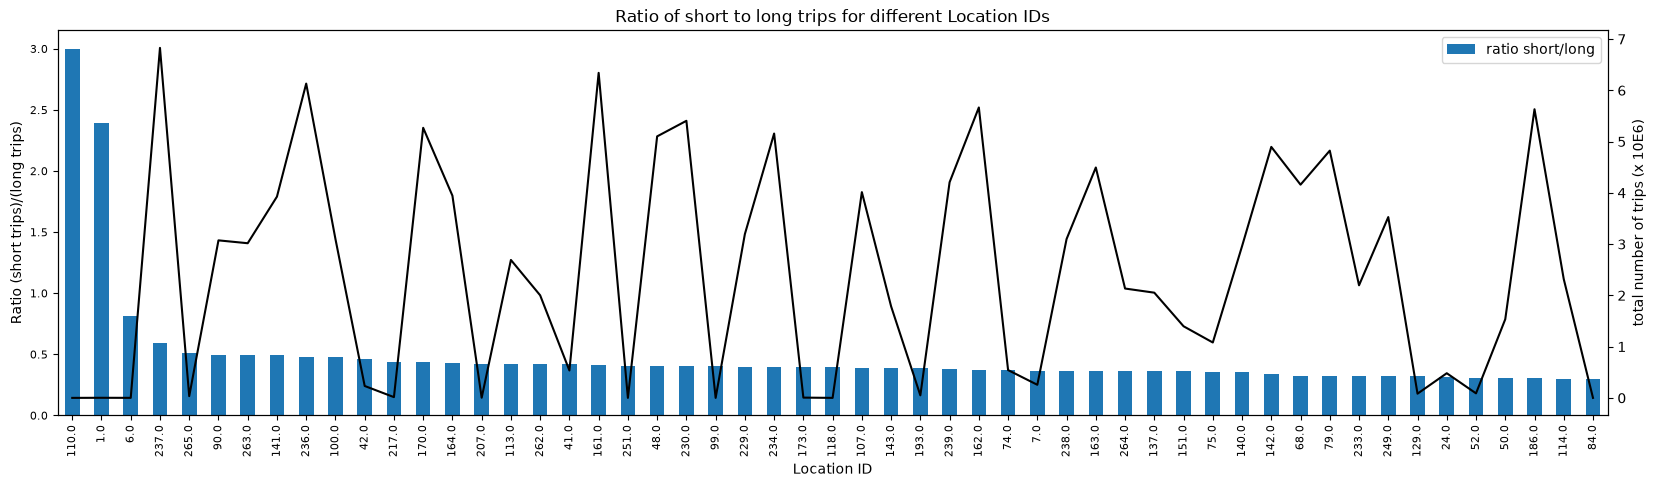

In [19]:
#trip ratio plots
import pandas as pd

plot_ratios_filt_pd = plot_ratios_filt.toPandas()

fig, axis1 = plt.subplots(figsize = (20,5))
plot_ratios_filt_pd.plot.bar(x = 'PULocationID', y = "ratio short/long", ax = axis1)
axis1.set_xlabel("Location ID")
axis1.set_ylabel("Ratio (short trips)/(long trips)")
axis1.tick_params(labelsize = 8)

axis2 = axis1.twinx()
axis2.set_ylabel("total number of trips (x 10E6)")
line1, = axis2.plot(plot_ratios_filt_pd["PULocationID"].astype(str), plot_ratios_filt_pd["total_trips"]/1e6, color = 'black')

plt.title("Ratio of short to long trips for different Location IDs")
plt.savefig("trip ratios")
plt.show()
